In [1]:
import rgb
from jax import numpy as jnp
from jax import vmap
from gaussians.gaussians import Gaussian
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap  # Had to add this myself to get LSC
from typing import Self

<H1>Create Gaussian Objects</H1>

$\large\text{From code shown in}$[[1,26:13]](#References)<br>

In [2]:
# Create a mean vector
mu = jnp.array([1.0, 2.0])
# Create a covariance matrix
Sigma = jnp.array([[1.0, 0.6], [0.6,2.0]])
# Create a Gaussian object
G = Gaussian(mu, Sigma)

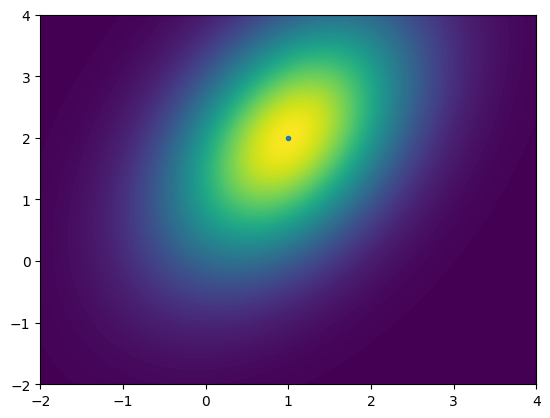

In [3]:
# rgb and LinearSegementedColormap do not work like Hennig's demo. Has something to do with running his "../preamble.py" that he does not share (I believe).
#cmp_wd = LinearSegmentedColormap.from_list("wd", ['w', rgb.tue_dark], N=1024)

X, Y = jnp.mgrid[-2:4:200j, -2:4:200j]
nplot = X.shape[0]
XY = jnp.dstack((X, Y)).reshape(nplot**2,2)
Z = vmap(G.pdf)(XY).reshape(nplot, nplot)

fig, ax = plt.subplots()
# This original line from Hennig isn't working becuase he doesn't share his "preample.py"
#ax.contourf(X, Y, Z, levels=200, cmap=cmp_we)
ax.contourf(X, Y, Z, levels=200)
# This original line from Hennig isn't working becuase he doesn't share his "preample.py"
# ax.plot(mu[0], mu[1], 'o', color=rgb.tue_green, markersize=3)
ax.plot(mu[0], mu[1], 'o', markersize=3)

<H1>Closure Properties</H1>

$\large\text{Products of Gaussian PDFs are Gaussian PDFs.}$[[1,27:37]](#References)<br>

In [4]:
# Create a mean vector
mu = jnp.array([1.0, 2.0, 3.0])
# Create a covariance matrix
Sigma = jnp.array([[1.0, 0.5, 0.0], [0.5, 2.0, 0.0], [0.0, 0.0, 2.0]])
# Create two Gaussian objects
g1 = Gaussian(mu, Sigma)
g2 = Gaussian(mu, Sigma)
# Get the product of the two Gaussian objects
g3 = g1 * g2
g1, g2, g3

(Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([1.      , 2.      , 3.000001], dtype=float32), Sigma=Array([[0.50000006, 0.2500001 , 0.        ],
        [0.25000012, 1.0000002 , 0.        ],
        [0.        , 0.        , 1.0000001 ]], dtype=float32)))

$\large\text{Shifts of Gaussian PDFs are also Gaussian PDFs}$[[1,27:37]](#References)<br>
$\large\text{If }p(x)=\mathcal{N}(x;\mu,\Sigma)\text{, then }p(z=x+b)=\mathcal{N}(z;\mu+b,\Sigma).$[[1,28:23]](#References)<br>

In [5]:
# Create a Gaussian object
g = Gaussian(mu,Sigma)
# Shift the Gaussian object
g2 = g + 3.
g, g2

(Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([4., 5., 6.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)))

$\large\text{Linear Projections of Gaussian PDFs are Gaussian PDFs.}$[[1,34:31]](#References)[[1,36:04]](#References)<br>
$\large\text{Let }p(x)=\mathcal{N}(x;\mu,\Sigma)$<br>
$\large\text{then }p(Ax)=\mathcal{N}(Ax,A\mu,A\Sigma A^{T})$<br>


In [6]:
# This code is from [1,34:31] of course lecture material
# Create a Gaussian object
g = Gaussian(mu,Sigma)

# Project the Gaussian object linearly using A
A = jnp.array([[1, 1, 0], [0, 2, 1]])
g2 = A @ g
g2

Gaussian(mu=Array([3., 7.], dtype=float32), Sigma=Array([[ 4.,  5.],
       [ 5., 10.]], dtype=float32))

$\large\text{Marginals of Gaussian PDFs are Gaussian PDFs.}$[[1,36:04]](#References)<br>

In [7]:
# This code is based on [1,36:04] of course lecture material
# Create a Gaussian object
g = Gaussian(mu,Sigma)
# Show some of the marginal distributions that result
g, g[0], g[1], g[0:2]

(Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([1.], dtype=float32), Sigma=Array([[1.]], dtype=float32)),
 Gaussian(mu=Array([2.], dtype=float32), Sigma=Array([[2.]], dtype=float32)),
 Gaussian(mu=Array([1., 2.], dtype=float32), Sigma=Array([[1. , 0.5],
        [0.5, 2. ]], dtype=float32)))

$\large\text{ Sums of Gaussian PDFs are Guassian PDFs.}$[[1,26:01]](#References)<br>

In [8]:
# Create a two Gaussian objeccts
g1 = Gaussian(mu, Sigma)
g2 = Gaussian(mu*2, Sigma*3)
g3 = g1 + g2
g1, g2, g3

(Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([2., 4., 6.], dtype=float32), Sigma=Array([[3. , 1.5, 0. ],
        [1.5, 6. , 0. ],
        [0. , 0. , 6. ]], dtype=float32)),
 Gaussian(mu=Array([3., 6., 9.], dtype=float32), Sigma=Array([[4., 2., 0.],
        [2., 8., 0.],
        [0., 0., 8.]], dtype=float32)))

$\large\text{Sums of Gaussian Random Variables are Gaussian PDFs.}$[[1,39:15]](#References)<br>

$\large p(z)=\mathcal{N}(z; \mu, \Sigma)\rightarrow p(Az)=\mathcal{N}(Az, A\mu, A,\Sigma A^{T})$<br>
$\large\text{Choose }A=\begin{pmatrix}1 & 1\end{pmatrix}\text{ and consider}$<br>
$\large p(x,y)=\mathcal{N}\left[\begin{pmatrix}x \\ y \end{pmatrix}; \begin{pmatrix}\mu_{x} \\ \mu_{y} \end{pmatrix}, \begin{pmatrix} \Sigma_{xx} & 0 \\ 0 & \Sigma_{xx}\end{pmatrix}\right]$<br>
$\large\text{Now see that } p(x + y)=\mathcal{N}\left[x+y;\mu_{x}+\mu{y},\Sigma_{xx} + \Sigma_{yy}\right]$[[1,39:34]](#References)<br>

$\large\text{As a Corollary, Gaussian PDFs are close under affine transformations.}$[[1,39:53]](#References)<br>

$\large p(x|Ax=y)=\frac{p(x,y)}{p(y)}$<br>
$\large\quad\quad=\mathcal{N}(x;\mu+\Sigma A^{T}(A\Sigma A^{T})^{-1}(y-A\mu), \Sigma-\Sigma A^{T}(A\Sigma A^{T})^{-1}A\Sigma)$[[1,40:18]](#References)$<br>

In [9]:
# Create two Gaussian objeccts
g1 = Gaussian(mu, Sigma)
g2 = Gaussian(mu*2, Sigma*3)
A = jnp.array([[1 ,0, 0], [0, 1, 0]])
B = jnp.array([[0 ,0, 1], [0, 1, 0]])
g3 = A @ g1 + B @ g2
g3


Gaussian(mu=Array([7., 6.], dtype=float32), Sigma=Array([[7. , 0.5],
       [0.5, 8. ]], dtype=float32))

$\large\text{Cuts (linear conditionals) of Gaussian PDFs are Gaussian PDFs.}$[[1,44:11]](#References)<br>
$\large\text{If }y=Ax+\epsilon\text{ with }\epsilon\sim\mathcal{N}(0,\Lambda)\text{ then }$<br>
$\large\quad\quad=\mathcal{N}(x;\mu+\Sigma A^{T}(A\Sigma A^{T})^{-1}(y-A\mu), \Sigma-\Sigma A^{T}(A\Sigma A^{T})^{-1}A\Sigma)$[[1,44:11]](#References)$<br>

In [10]:
g = Gaussian(mu, Sigma)
A = jnp.array([[1, 1, 0], [0, 2, 1]])
Lambda = 0.2 * jnp.eye(2)
y = jnp.array([1, 2])
g2 = g.condition(A, y, Lambda)
g, g2

(Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
        [0.5, 2. , 0. ],
        [0. , 0. , 2. ]], dtype=float32)),
 Gaussian(mu=Array([0.7701794 , 0.17825103, 1.766816  ], dtype=float32), Sigma=Array([[ 0.31894612, -0.2034753 ,  0.3699552 ],
        [-0.20347536,  0.26513433, -0.48206282],
        [ 0.36995524, -0.4820629 ,  1.0582957 ]], dtype=float32)))

<H1>Examples of Covariance Structure</H1>

$\large\text{Conditional independence.}$[[1,1:08:14]](#References)<br>

Gaussian(mu=Array([0., 0., 0.], dtype=float32), Sigma=Array([[  117.,    90.,  2070.],
       [   90.,   100.,  2300.],
       [ 2070.,  2300., 52925.]], dtype=float32))
[[ 2.7783245e-02 -2.5603389e-02  2.6006483e-05]
 [-2.5603389e-02  2.1696112e+01 -9.4186091e-01]
 [ 2.6006437e-05 -9.4186085e-01  4.0948950e-02]]


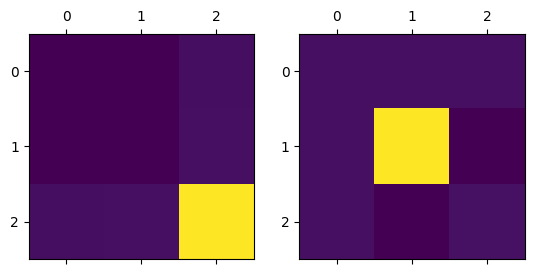

In [11]:
Nu = Gaussian(jnp.zeros(3), jnp.diag(jnp.array([6,10,5]))**2)
w1 = 0.9
w2 = 1.1
W = jnp.array([[1, w1, 0],[0,1,0],[0,23,1]])
X = W @ Nu
print(X)
print(X.precision)
fit , ax = plt.subplots(1,2)
ax[0].matshow(X.Sigma)
ax[1].matshow(X.precision)

In [12]:
Mu = jnp.array([55,16])
Sigma = jnp.diag(jnp.array([2,0.5])**2)
prior = Gaussian(mu, Sigma)
prior

Gaussian(mu=Array([1., 2., 3.], dtype=float32), Sigma=Array([[4.  , 0.  ],
       [0.  , 0.25]], dtype=float32))

In [14]:
# From [1,1:22:13]
A = jnp.array([2.1, 1.1]).reshape(1,2)
sigma2 = jnp.array([3.5**2])
y = 33
A @ prior.Sigma @ A.T + sigma2
posterior = prior.condition(A, y, sigma2)
posterior

TypeError: dot_general requires contracting dimensions to have the same shape, got (2,) and (3,).

<H1>References</H1>

[1.] Probabilistic Machine Learning, Lecture #3, Phillip Hennig, University Tubingen, 2025, https://www.youtube.com/watch?v=CXCNoAw3YYM&list=PL05umP7R6ij0hPfU7Yuz8J9WXjlb3MFjm&index=3.